In [14]:
# Implementation of ry_feature_map suitable for a quantum kernel
from qiskit import QuantumCircuit
import numpy as np

def ry_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map with two Ry encoding layers separated by a configurable
    entanglement block.


    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # First encoding layer
    for q in range(n_qubits):
        qc.ry(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        if n_qubits > 1:
            qc.cx(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cx(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    # Second encoding layer (same qubits, same encoding type)
    for q in range(n_qubits):
        qc.ry(arr[q], q)

    return qc

In [16]:
def phase_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map that encodes `data` as Z-phase rotations (Rz) on each qubit
    after preparing equal superposition states with Hadamards, using two encoding
    layers separated by a configurable entanglement block.


    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # Prepare |+> states on all qubits
    for q in range(n_qubits):
        qc.h(q)

    # First encoding layer
    for q in range(n_qubits):
        qc.rz(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
        if n_qubits > 1:
            qc.cz(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cz(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    # Second encoding layer (same qubits, same encoding type)
    for q in range(n_qubits):
        qc.rz(arr[q], q)

    return qc

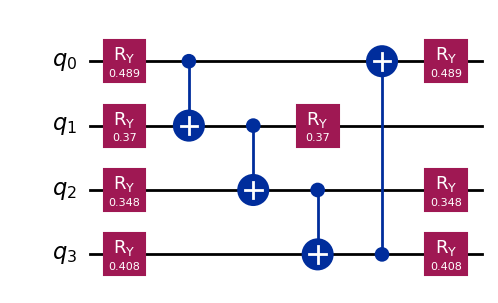

In [15]:
# Example usage: construct and visualize a circuit for 4 qubits
from qiskit.visualization import circuit_drawer

# Example data (must have length equal to n_qubits)
data = [0.48854, 0.36986, 0.34778, 0.40850]
qc = ry_feature_map(4, data, entanglement="ring")

# Display the circuit in the notebook (uses matplotlib if available)
qc.draw(output="mpl")

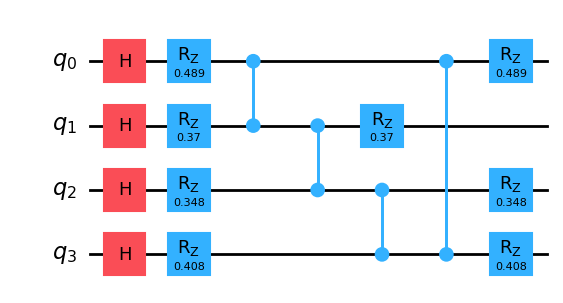

In [17]:
# Example usage: construct and visualize a circuit for 4 qubits
from qiskit.visualization import circuit_drawer

# Example data (must have length equal to n_qubits)
data = [0.48854, 0.36986, 0.34778, 0.40850]
qc = phase_feature_map(4, data, entanglement="ring")

# Display the circuit in the notebook (uses matplotlib if available)
qc.draw(output="mpl")

## Datuak kargau

### EEG

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

# Cargar dataset preprocesado, con feature extraction
data = np.load("data/processed_features.npz", allow_pickle=True)

# Para encodings cuánticos: usa ángulos
X = data["X_angle"]          # shape: (n_windows, n_features)
# Si quieres probar sin ángulos: X = data["X_raw"]

y = data["y"]                # 0/1
y_name = data["y_name"]      # 'norm'/'sch'
feature_names = data["feature_names"]

# Split estratificado (mantiene proporción norm/sch)
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
y_name_train, y_name_test = y_name[idx_train], y_name[idx_test]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Clases train:", dict(zip(*np.unique(y_name_train, return_counts=True))))
print("Clases test :", dict(zip(*np.unique(y_name_test, return_counts=True))))
print("Rango angular train:", float(X_train.min()), float(X_train.max()))

X_train: (64444, 19) | X_test: (16112, 19)
Clases train: {np.str_('norm'): np.int64(29920), np.str_('sch'): np.int64(34524)}
Clases test : {np.str_('norm'): np.int64(7481), np.str_('sch'): np.int64(8631)}
Rango angular train: -3.141592653589793 3.141592653589793


In [8]:
# Subsets para acelerar entrenamiento/evaluación
# Usa las fracciones ya definidas en el notebook: train_frac y test_frac
train_frac = 0.2
test_frac = 0.2

X_train_sub, _, y_train_sub, _, y_name_train_sub, _ = train_test_split(
    X_train, y_train, y_name_train,
    train_size=train_frac,
    random_state=42,
    stratify=y_train
)

X_test_sub, _, y_test_sub, _, y_name_test_sub, _ = train_test_split(
    X_test, y_test, y_name_test,
    train_size=test_frac,
    random_state=42,
    stratify=y_test
)

print("Train original:", X_train.shape, "-> subset:", X_train_sub.shape)
print("Test  original:", X_test.shape,  "-> subset:", X_test_sub.shape)

print("Clases train subset:", dict(zip(*np.unique(y_name_train_sub, return_counts=True))))
print("Clases test  subset:", dict(zip(*np.unique(y_name_test_sub, return_counts=True))))

Train original: (64444, 19) -> subset: (12888, 19)
Test  original: (16112, 19) -> subset: (3222, 19)
Clases train subset: {np.str_('norm'): np.int64(5984), np.str_('sch'): np.int64(6904)}
Clases test  subset: {np.str_('norm'): np.int64(1496), np.str_('sch'): np.int64(1726)}


In [9]:
print(X_train)

[[-3.02335451 -2.48234902 -3.02335451 ... -3.09976331 -2.96813184
  -3.02287845]
 [-2.87333128 -2.04103607 -2.87333128 ... -3.06576022 -3.00634853
  -2.8720452 ]
 [-2.93375118 -2.19952835 -2.93375118 ... -3.07910436 -2.99647208
  -2.93319718]
 ...
 [-2.81107256 -1.89478086 -2.81107256 ... -2.96072948 -2.88518934
  -2.81091068]
 [-2.87807782 -2.05282508 -2.87807782 ... -3.07633281 -3.0222948
  -2.87784191]
 [-2.7702634  -1.80606011 -2.7702634  ... -2.95585281 -2.90708886
  -2.76828596]]


In [ ]:
from qiskit.quantum_info import Statevector
# =========================
# Quantum kernel (fidelidad)
# =========================
def _state(x,fm):
    if(fm == "ry"):
        qc = ry_feature_map(n_qubits=len(x), data=x, entanglement="ring")
    elif(fm == "rz"):
        qc = phase_feature_map(n_qubits=len(x), data=x, entanglement="ring")
    else:
        raise ValueError("Unsupported feature map. Choose 'ry' or 'rz'.")
    return Statevector.from_instruction(qc).data

def _fidelity(x1, x2,fm):
    psi1 = _state(x1,fm)
    psi2 = _state(x2,fm)
    return float(np.abs(np.vdot(psi1, psi2)) ** 2)

def kernel_matrix(A, B,fm):
    K = np.zeros((len(A), len(B)), dtype=np.float64)
    for i in range(len(A)):
        for j in range(len(B)):
            K[i, j] = _fidelity(A[i], B[j],fm)
    return K

In [ ]:
print(X_train.shape)

(64444, 19)


In [22]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import numpy as np

# =========================
# Configuración rápida
# =========================
n_qubits = 8       # usa las primeras 8 features (1 feature por qubit)
n_train = 300    # reduce para que no tarde demasiado
n_test = 150

X_train_q = X_train_sub[:n_train, :n_qubits]
X_test_q  = X_test_sub[:n_test, :n_qubits]
y_train_q = y_train_sub[:n_train]
y_test_q  = y_test_sub[:n_test]

print("Shapes:", X_train_q.shape, X_test_q.shape)



K_train = kernel_matrix(X_train_q, X_train_q,fm="rz")
K_test  = kernel_matrix(X_test_q, X_train_q,fm="rz")

print("K_train:", K_train.shape, "| K_test:", K_test.shape)

# =========================
# SVM con kernel precomputado
# =========================
clf = SVC(kernel="precomputed", C=1.0)
clf.fit(K_train, y_train_q)
y_pred = clf.predict(K_test)

print("Accuracy:", accuracy_score(y_test_q, y_pred))
print(classification_report(y_test_q, y_pred, target_names=["norm", "sch"]))

Shapes: (300, 8) (150, 8)
K_train: (300, 300) | K_test: (150, 300)
Accuracy: 0.64
              precision    recall  f1-score   support

        norm       0.71      0.39      0.50        70
         sch       0.62      0.86      0.72        80

    accuracy                           0.64       150
   macro avg       0.66      0.62      0.61       150
weighted avg       0.66      0.64      0.62       150



In [ ]:


from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import numpy as np

# =========================
# Configuración rápida
# =========================
n_qubits = 8       # usa las primeras 8 features (1 feature por qubit)
n_train = 300      # reduce para que no tarde demasiado
n_test = 150

X_train_q = X_train[:n_train, :n_qubits]
X_test_q  = X_test[:n_test, :n_qubits]
y_train_q = y_train[:n_train]
y_test_q  = y_test[:n_test]

print("Shapes:", X_train_q.shape, X_test_q.shape)



K_train = kernel_matrix(X_train_q, X_train_q,fm="ry")
K_test  = kernel_matrix(X_test_q, X_train_q,fm="ry")

print("K_train:", K_train.shape, "| K_test:", K_test.shape)

# =========================
# SVM con kernel precomputado
# =========================
clf = SVC(kernel="precomputed", C=1.0)
clf.fit(K_train, y_train_q)
y_pred = clf.predict(K_test)

print("Accuracy:", accuracy_score(y_test_q, y_pred))
print(classification_report(y_test_q, y_pred, target_names=["norm", "sch"]))

Shapes: (300, 8) (150, 8)
K_train: (300, 300) | K_test: (150, 300)
Accuracy: 0.6333333333333333
              precision    recall  f1-score   support

        norm       0.66      0.30      0.41        64
         sch       0.63      0.88      0.73        86

    accuracy                           0.63       150
   macro avg       0.64      0.59      0.57       150
weighted avg       0.64      0.63      0.60       150

Accuracy: 0.6333333333333333
              precision    recall  f1-score   support

        norm       0.66      0.30      0.41        64
         sch       0.63      0.88      0.73        86

    accuracy                           0.63       150
   macro avg       0.64      0.59      0.57       150
weighted avg       0.64      0.63      0.60       150



In [10]:
import matplotlib.pyplot as plt


def analyze_kernel_geometry(X_train_data, X_test_data, fm, *, name=None):
    """Compute quantum kernels and report geometric diagnostics."""
    K_train = kernel_matrix(X_train_data, X_train_data, fm=fm)
    K_test = kernel_matrix(X_test_data, X_train_data, fm=fm)

    # Symmetrize to remove tiny numerical asymmetries before eigendecomposition.
    K_sym = 0.5 * (K_train + K_train.T)
    eigvals = np.linalg.eigvalsh(K_sym)

    diag = np.diag(K_train)
    off_diag = K_train[~np.eye(K_train.shape[0], dtype=bool)]

    trace = float(np.trace(K_sym))
    fro_norm = float(np.linalg.norm(K_sym, ord="fro"))
    effective_rank = (trace ** 2) / (fro_norm ** 2 + 1e-12)

    min_eig = float(np.min(eigvals))
    max_eig = float(np.max(eigvals))
    cond_number = float(max_eig / max(min_eig, 1e-12))

    label = name or fm
    print(f"\n=== Geometric analysis: {label} ===")
    print("K_train shape:", K_train.shape, "| K_test shape:", K_test.shape)
    print("Symmetry error ||K-K^T||_F:", float(np.linalg.norm(K_train - K_train.T, ord="fro")))
    print("Diagonal mean/std:", float(np.mean(diag)), float(np.std(diag)))
    print("Off-diagonal mean/std:", float(np.mean(off_diag)), float(np.std(off_diag)))
    print("Eigenvalue min/max:", min_eig, max_eig)
    print("Effective rank:", float(effective_rank))
    print("Condition number (PSD approx):", cond_number)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    im0 = axes[0].imshow(K_train, aspect="auto", cmap="viridis")
    axes[0].set_title(f"{label} - K_train")
    axes[0].set_xlabel("train idx")
    axes[0].set_ylabel("train idx")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].plot(np.sort(eigvals)[::-1], marker="o", linewidth=1)
    axes[1].set_title(f"{label} - eig spectrum")
    axes[1].set_xlabel("index")
    axes[1].set_ylabel("eigenvalue")

    axes[2].hist(off_diag, bins=30, alpha=0.9)
    axes[2].set_title(f"{label} - off-diagonal histogram")
    axes[2].set_xlabel("K_ij (i!=j)")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

    return {
        "K_train": K_train,
        "K_test": K_test,
        "eigvals": eigvals,
        "effective_rank": effective_rank,
        "cond_number": cond_number,
    }



=== Geometric analysis: Phase (RZ) ===
K_train shape: (200, 200) | K_test shape: (100, 200)
Symmetry error ||K-K^T||_F: 0.0
Diagonal mean/std: 0.9999999999999974 7.746143079195814e-16
Off-diagonal mean/std: 0.18402172384790985 0.24019033845098414
Eigenvalue min/max: 8.333812503140851e-07 51.323007196099454
Effective rank: 10.406085350915147
Condition number (PSD approx): 61584067.5282253


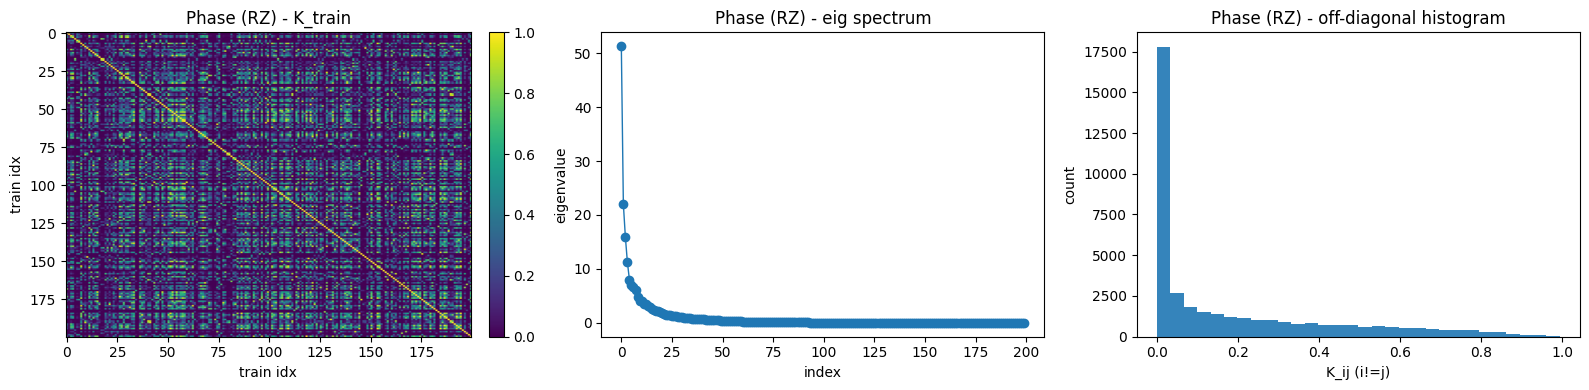


=== Geometric analysis: Amplitude (RY) ===
K_train shape: (200, 200) | K_test shape: (100, 200)
Symmetry error ||K-K^T||_F: 0.0
Diagonal mean/std: 1.0 8.217150546646994e-16
Off-diagonal mean/std: 0.3110106257759003 0.28691418764272386
Eigenvalue min/max: 1.3355673755627315e-07 76.70474447753506
Effective rank: 5.459942152278184
Condition number (PSD approx): 574323286.7246108


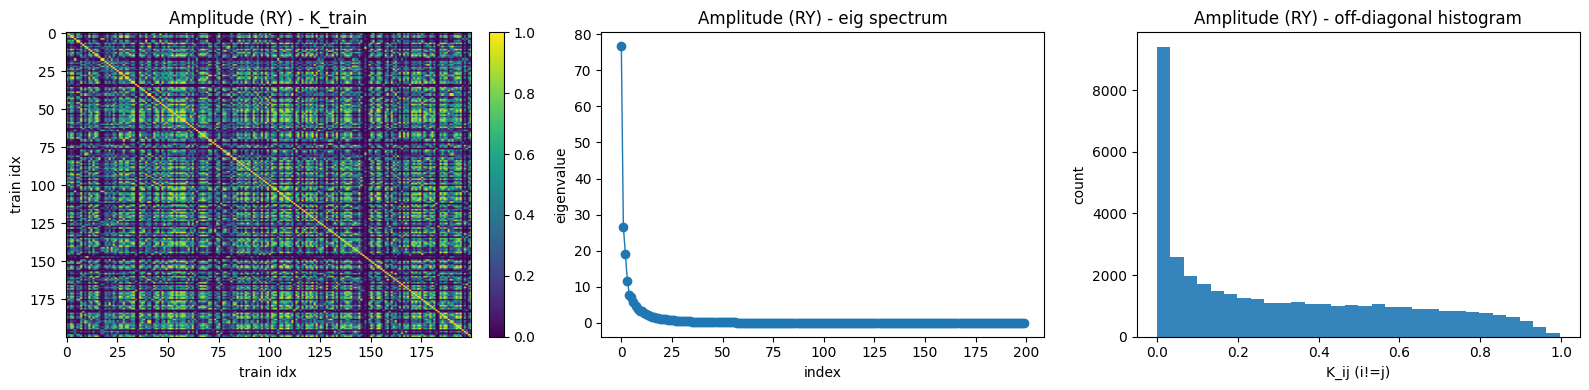

In [19]:
# Comparación geométrica con el mismo subset para ambos feature maps
n_qubits_geom = 8
n_train_geom = 200
n_test_geom = 100

X_train_geom = X_train[:n_train_geom, :n_qubits_geom]
X_test_geom = X_test[:n_test_geom, :n_qubits_geom]

geom_rz = analyze_kernel_geometry(X_train_geom, X_test_geom, fm="rz", name="Phase (RZ)")
geom_ry = analyze_kernel_geometry(X_train_geom, X_test_geom, fm="ry", name="Amplitude (RY)")